## Setup & Imports

In [19]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
import torchvision.transforms.functional as TF
from PIL import Image
from sklearn.model_selection import train_test_split
from torch import optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

data_root = Path("../data/forest-aerial-images/Forest Segmented/Forest Segmented")


meta = pd.read_csv(data_root / "meta_data.csv")
print(meta.shape)
meta.head()

(5108, 2)


,image,mask
0,10452_sat_08.jpg,10452_mask_08.jpg
1,10452_sat_18.jpg,10452_mask_18.jpg
2,111335_sat_00.jpg,111335_mask_00.jpg
3,111335_sat_01.jpg,111335_mask_01.jpg
4,111335_sat_02.jpg,111335_mask_02.jpg


## Device Setup

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load Metadata & Inspect One Sample

image     626208_sat_52.jpg
mask     626208_mask_52.jpg
Name: 2774, dtype: str


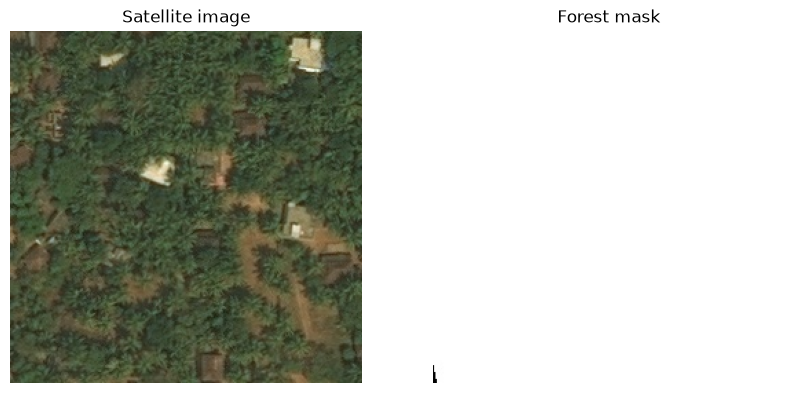

In [21]:
sample_row = meta.iloc[random.randint(0, len(meta)-1)]
print(sample_row)

image_path = data_root / "images" / sample_row["image"]
mask_path = data_root / "masks" / sample_row["mask"]

image = Image.open(image_path)
mask = Image.open(mask_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title("Satellite image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Forest mask")
axes[1].axis("off")

plt.show()

## Check Mask Pixel Values (raw, unclean)

In [22]:
mask_array = np.array(mask)
print("Shape:", mask_array.shape)
print("Data type:", mask_array.dtype)
print("Unique pixel values:", np.unique(mask_array))

Shape: (256, 256, 3)
Data type: uint8
Unique pixel values: [  0   1   2   3 250 251 252 253 254 255]


## Clean Mask — Convert to Binary

Unique values after thresholding: [0 1]


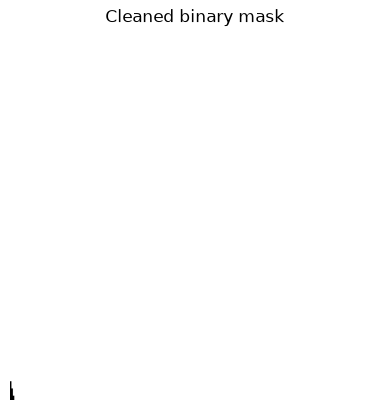

In [23]:
mask_gray = mask.convert("L")  # collapse to single channel
mask_array_clean = np.array(mask_gray)

binary_mask = (mask_array_clean >= 128).astype(np.uint8)
print("Unique values after thresholding:", np.unique(binary_mask))

plt.imshow(binary_mask, cmap="gray")
plt.title("Cleaned binary mask")
plt.axis("off")
plt.show()

## Dataset-Wide Class Balance Check

Mean forest coverage: 61.5%
Min: 0.2%, Max: 99.9%


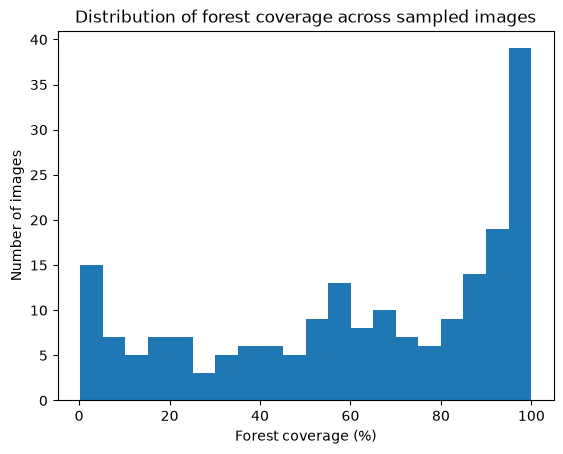

In [ ]:
sample_size = 200
sample_rows = meta.sample(n=sample_size, random_state=42)

forest_pixel_fraction = []

for _, row in sample_rows.iterrows():
    m_path = data_root / "masks" / row["mask"]
    m = Image.open(m_path).convert("L")
    m_array = np.array(m)
    binary = (m_array >= 128).astype(np.uint8)
    forest_pixel_fraction.append(binary.mean())

forest_pixel_fraction = np.array(forest_pixel_fraction)
print(f"Mean forest coverage: {forest_pixel_fraction.mean() * 100:.1f}%")
print(
    f"Min: {forest_pixel_fraction.min() * 100:.1f}%, Max: {forest_pixel_fraction.max() * 100:.1f}%"
)

plt.hist(forest_pixel_fraction * 100, bins=20)
plt.xlabel("Forest coverage (%)")
plt.ylabel("Number of images")
plt.title("Distribution of forest coverage across sampled images")
plt.show()

## Custom Dataset Class (image+mask sync augmentation)

In [25]:
class ForestSegmentationDataset(Dataset):
    def __init__(self, dataframe, data_root, augment=False):
        self.dataframe = dataframe
        self.data_root = data_root
        self.augment = augment
        self.color_jitter = transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.3
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(
            self.data_root / "images" / row["image"]
        ).convert("RGB")
        
        mask = Image.open(self.data_root / "masks" / row["mask"]).convert("L")

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)
            angle = random.choice([0, 90, 180, 270])
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

            image = self.color_jitter(image)  # image only — color doesn't affect mask

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        mask = (mask >= 0.5).float()

        return image, mask

## Instantiate Dataset & Pull One Sample (sanity check)

In [26]:
dataset = ForestSegmentationDataset(meta, data_root, augment=True)

image, mask = dataset[0]

print("Image shape:", image.shape, "dtype:", image.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype)
print("Mask unique values:", torch.unique(mask))

Image shape: torch.Size([3, 256, 256]) dtype: torch.float32
Mask shape: torch.Size([1, 256, 256]) dtype: torch.float32
Mask unique values: tensor([0., 1.])


## Visualize Augmented Image/Mask Pairs

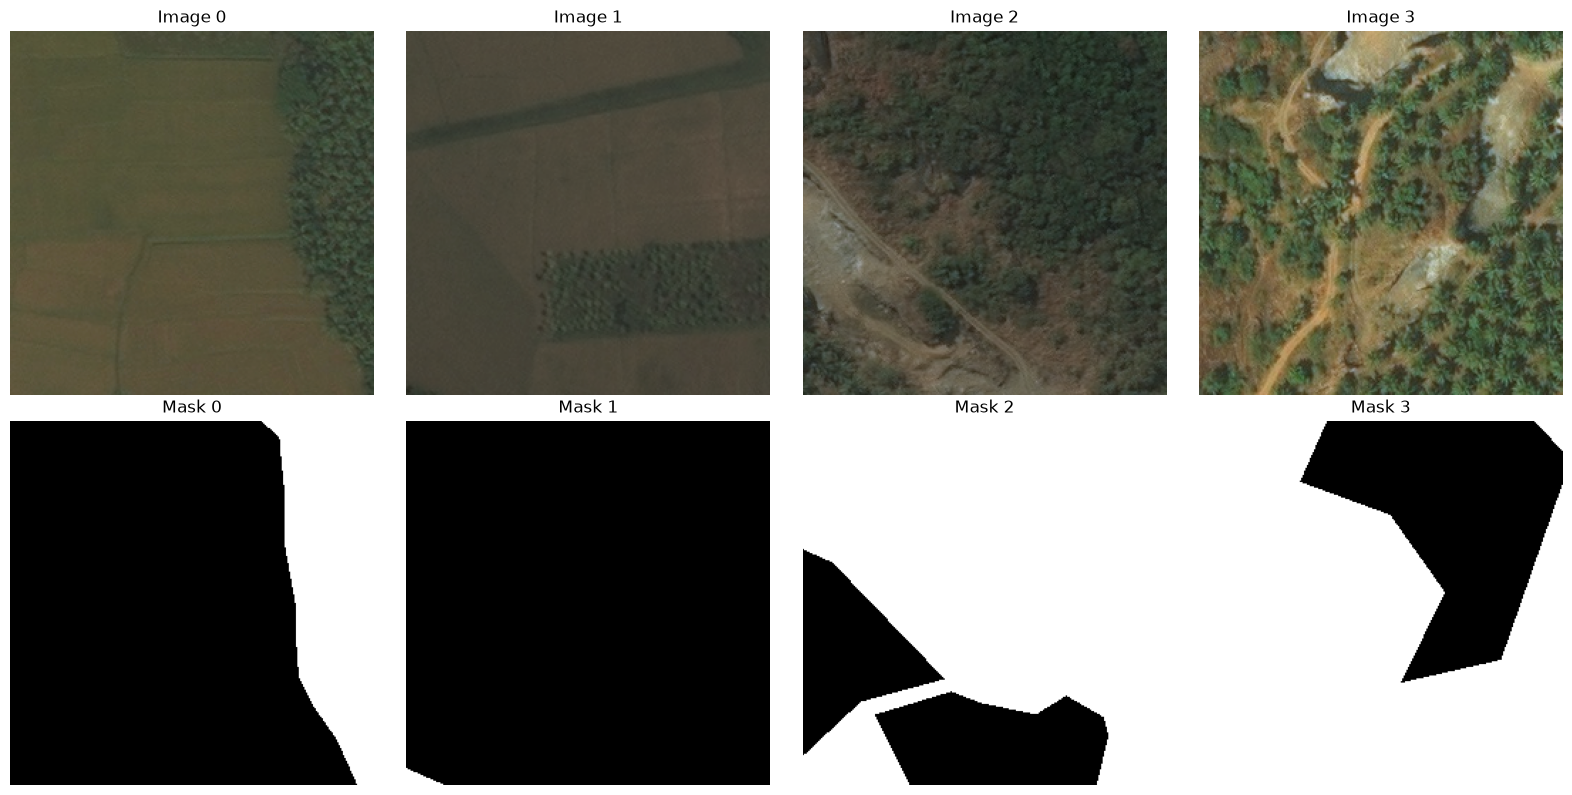

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    image, mask = dataset[i]
    axes[0, i].imshow(image.permute(1, 2, 0))  # (C,H,W) -> (H,W,C) for matplotlib
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(mask.squeeze(), cmap="gray")
    axes[1, i].set_title(f"Mask {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Train/Val Split

In [28]:
train_df, val_df = train_test_split(meta, test_size=0.2, random_state=42)

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}")

train_dataset = ForestSegmentationDataset(train_df, data_root, augment=True)
val_dataset = ForestSegmentationDataset(val_df, data_root, augment=False)

Train size: 4086, Val size: 1022


## DataLoaders

In [29]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

images, masks = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch masks shape:", masks.shape)

Batch images shape: torch.Size([16, 3, 256, 256])
Batch masks shape: torch.Size([16, 1, 256, 256])


## Transfer Learning Segmentation Model

In [30]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

# print(model)

## Model Sanity Check (forward pass shape test)

In [31]:
model.eval()
with torch.no_grad():
    sample_images, sample_masks = next(iter(train_loader))
    sample_images = sample_images.to(device)
    output = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([16, 3, 256, 256])
Output shape: torch.Size([16, 1, 256, 256])


## Loss Function (Dice Loss)

In [32]:
dice_loss = smp.losses.DiceLoss(mode="binary")

sample_masks = sample_masks.to(device)
loss_value = dice_loss(output, sample_masks)
print("Sample Dice loss:", loss_value.item())

Sample Dice loss: 0.4464913010597229


## Optimizer (Adam + weight decay)

In [33]:
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

## Learning Rate Scheduler

In [34]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

## Accuracy Helper Function

In [35]:
def pixel_accuracy(preds, masks):
    preds_binary = (torch.sigmoid(preds) >= 0.5).float()
    correct = (preds_binary == masks).float().sum()
    total = torch.numel(masks)
    return (correct / total).item()

## Training Loop

In [36]:
num_epochs = 25
patience_early_stop = 5
epochs_no_improve = 0
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(num_epochs):
    model.train()
    running_loss, running_acc = 0.0, 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = dice_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_acc += pixel_accuracy(outputs, masks)

    train_loss = running_loss / len(train_loader)
    train_acc = running_acc / len(train_loader)

    model.eval()
    val_running_loss, val_running_acc = 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = dice_loss(outputs, masks)
            val_running_loss += loss.item()
            val_running_acc += pixel_accuracy(outputs, masks)

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_running_acc / len(val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | LR: {current_lr:.1e}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "../models/best_model.pt")
        print(f"  → Saved new best model (val loss: {val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience_early_stop:
            print(f"Early stopping triggered after {epoch + 1} epochs.")
            break

Epoch 1/25 | Train Loss: 0.2773, Train Acc: 0.7733 | Val Loss: 0.2091, Val Acc: 0.8167 | LR: 1.0e-04
  → Saved new best model (val loss: 0.2091)
Epoch 2/25 | Train Loss: 0.1880, Train Acc: 0.8095 | Val Loss: 0.1597, Val Acc: 0.8271 | LR: 1.0e-04
  → Saved new best model (val loss: 0.1597)
Epoch 3/25 | Train Loss: 0.1608, Train Acc: 0.8220 | Val Loss: 0.1544, Val Acc: 0.8214 | LR: 1.0e-04
  → Saved new best model (val loss: 0.1544)
Epoch 4/25 | Train Loss: 0.1518, Train Acc: 0.8223 | Val Loss: 0.1474, Val Acc: 0.8280 | LR: 1.0e-04
  → Saved new best model (val loss: 0.1474)
Epoch 5/25 | Train Loss: 0.1453, Train Acc: 0.8264 | Val Loss: 0.1381, Val Acc: 0.8308 | LR: 1.0e-04
  → Saved new best model (val loss: 0.1381)
Epoch 6/25 | Train Loss: 0.1430, Train Acc: 0.8268 | Val Loss: 0.1379, Val Acc: 0.8344 | LR: 1.0e-04
  → Saved new best model (val loss: 0.1379)
Epoch 7/25 | Train Loss: 0.1391, Train Acc: 0.8293 | Val Loss: 0.1409, Val Acc: 0.8303 | LR: 1.0e-04
Epoch 8/25 | Train Loss: 0.13

## Plot Loss/Accuracy Curves

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Dice Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Pixel Accuracy")
axes[1].set_title("Accuracy over epochs")
axes[1].legend()

plt.tight_layout()
plt.savefig("loss_accuracy_curves.png", dpi=150)
plt.show()

NameError: name 'plt' is not defined

## Load Best Checkpoint

In [38]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
).to(device)

model.load_state_dict(torch.load("../models/best_model.pt", map_location=device))
model.eval()
print("Loaded best checkpoint.")

Loaded best checkpoint.


## show_prediction() Helper Function

In [39]:
def show_prediction(dataset, idx, model):
    image, true_mask = dataset[idx]

    with torch.no_grad():
        input_tensor = image.unsqueeze(0).to(device)
        output = model(input_tensor)
        pred_mask = (torch.sigmoid(output) >= 0.5).float().cpu().squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image.permute(1, 2, 0))
    axes[0].set_title("Satellite image")
    axes[0].axis("off")

    axes[1].imshow(true_mask.squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("True mask")
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Predicted mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## Random Validation Prediction Check

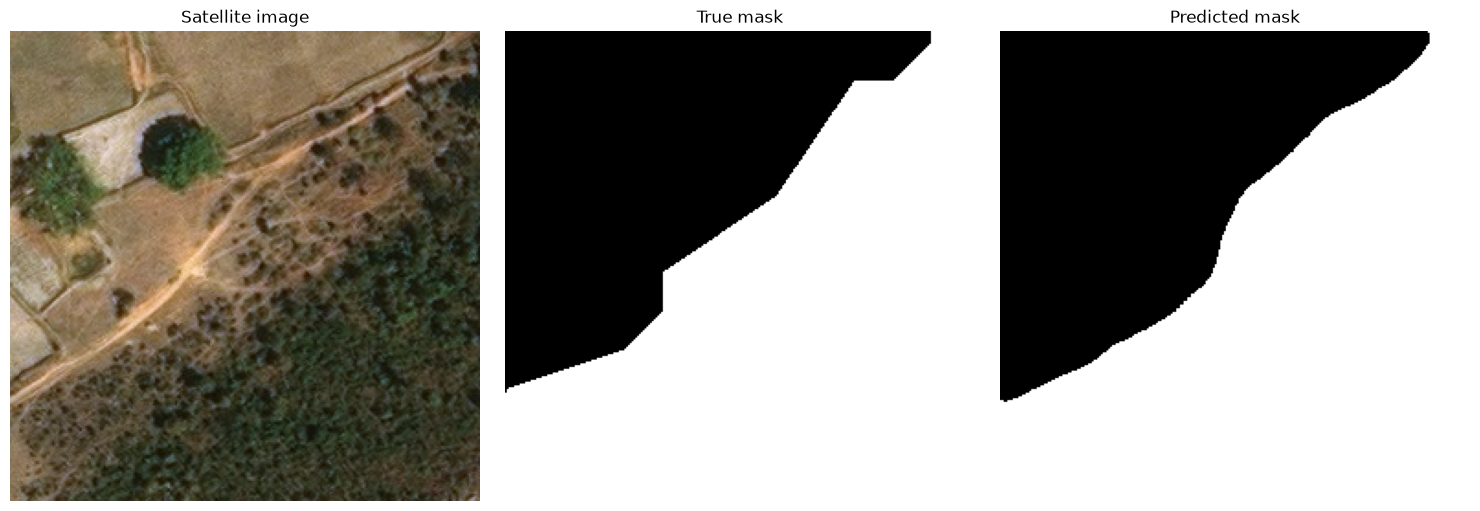

In [40]:
random_idx = random.randint(0, len(val_dataset) - 1)
show_prediction(val_dataset, random_idx, model)

## Investigation: Noisy Label Case Study (3484_sat_13)

In [ ]:
target_filename = "3484_sat_13.jpg"

if target_filename in val_df["image"].values:
    local_df = val_df.reset_index(drop=True)
    local_idx = local_df[local_df["image"] == target_filename].index[0]
    image, true_mask = val_dataset[local_idx]
else:
    local_df = train_df.reset_index(drop=True)
    local_idx = local_df[local_df["image"] == target_filename].index[0]
    image, true_mask = train_dataset[local_idx]

with torch.no_grad():
    input_tensor = image.unsqueeze(0).to(device)
    output = model(input_tensor)
    probs = torch.sigmoid(output)

print("Min probability:", probs.min().item())
print("Max probability:", probs.max().item())
print("Mean probability:", probs.mean().item())

Min probability: 0.7990441918373108
Max probability: 0.9989136457443237
Mean probability: 0.9974749088287354


Angle 0: mean prob = 0.9976, pred_mask min = 1.0, pred_mask max = 1.0
Angle 90: mean prob = 0.9976, pred_mask min = 1.0, pred_mask max = 1.0
Angle 180: mean prob = 0.9972, pred_mask min = 1.0, pred_mask max = 1.0
Angle 270: mean prob = 0.9975, pred_mask min = 1.0, pred_mask max = 1.0


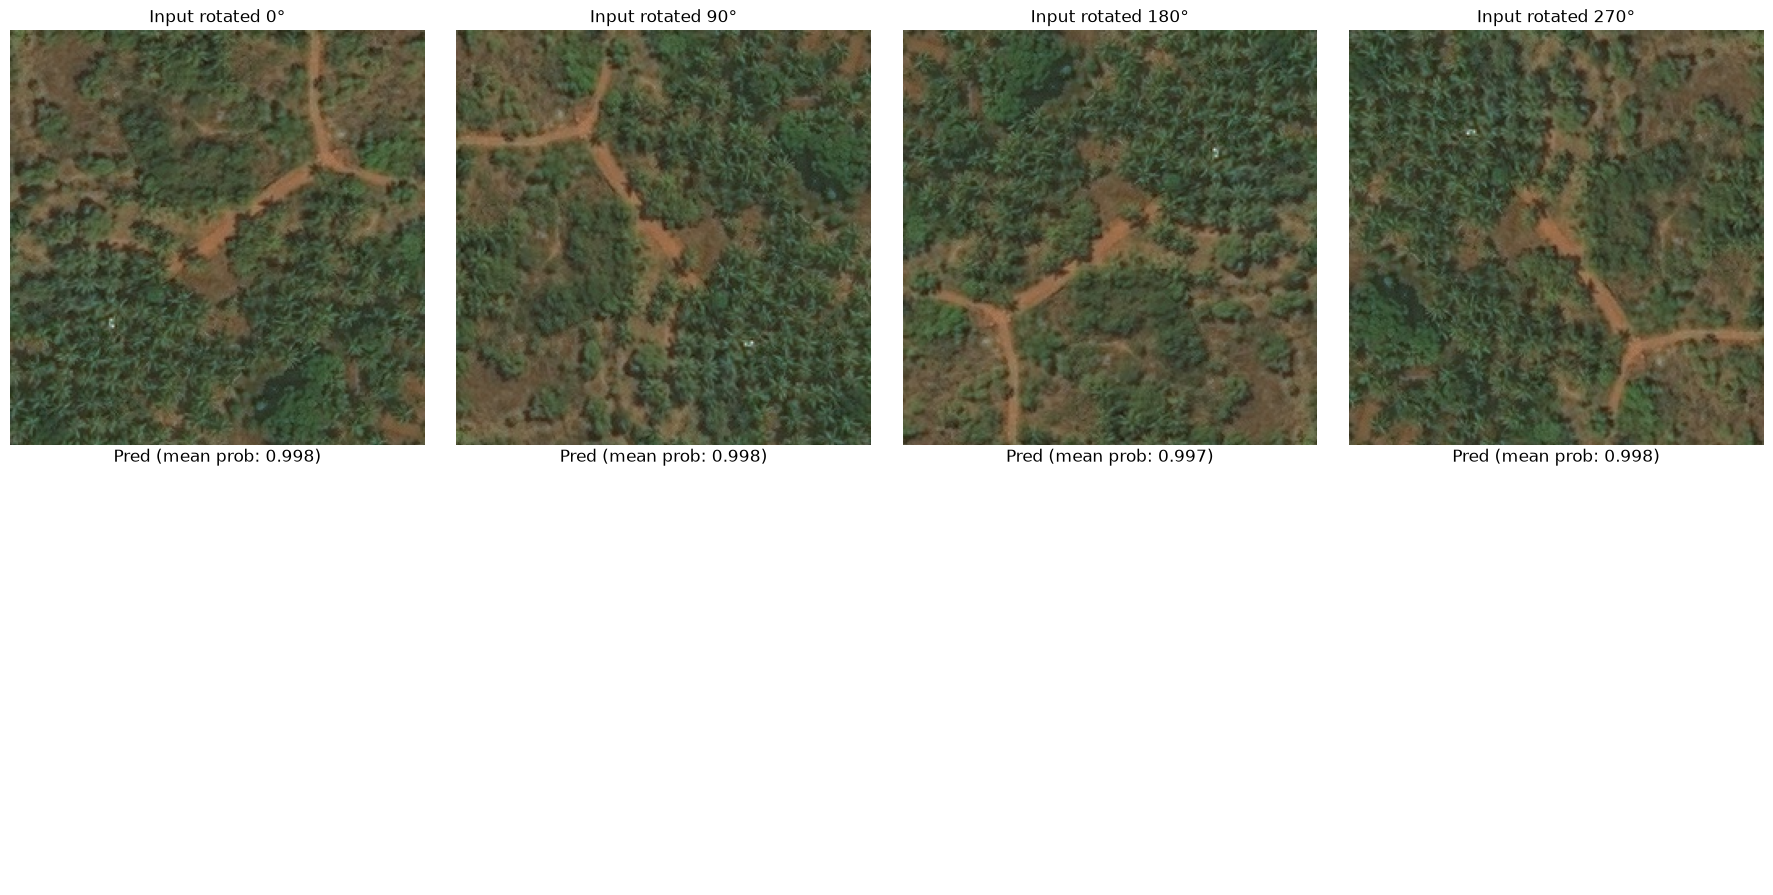

In [42]:
test_image_path = data_root / "images" / "3484_sat_13.jpg"
test_mask_path = data_root / "masks" / "3484_mask_13.jpg"

raw_image = Image.open(test_image_path).convert("RGB")
raw_mask = Image.open(test_mask_path).convert("L")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, angle in enumerate([0, 90, 180, 270]):
    rotated_image = TF.rotate(raw_image, angle)
    image_tensor = TF.to_tensor(rotated_image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.sigmoid(output)
        pred_mask = (probs >= 0.5).float().cpu().squeeze()
        print(
            f"Angle {angle}: mean prob = {probs.mean().item():.4f}, pred_mask min = {pred_mask.min().item()}, pred_mask max = {pred_mask.max().item()}"
        )

    axes[0, i].imshow(rotated_image)
    axes[0, i].set_title(f"Input rotated {angle}°")
    axes[0, i].axis("off")

    axes[1, i].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Pred (mean prob: {probs.mean().item():.3f})")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Using the model

In [43]:
def predict_on_image(image_path, model):
    img = Image.open(image_path).convert("RGB")
    img_tensor = TF.to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred_mask = (torch.sigmoid(output) >= 0.5).float().cpu().squeeze()

    plt.imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    plt.title("Predicted forest mask")
    plt.axis("off")
    plt.show()


# predict_on_image("../data/.../images/some_image.jpg", model)

## External Data Resize Test

In [ ]:
# To experiement on external data I created this function to format and print resized images to work with the model created
# To try this simply add any aerial image(s) of a forest in the data/external_forest_test and run these following code cells 

def resize_and_save(folder_path, multiple_of=32):
    folder_path = Path(folder_path)
    image_paths = sorted(folder_path.glob("*"))
    resized_paths = []

    for img_path in image_paths:
        name = img_path.stem
        ext = img_path.suffix

        if name.endswith("_resized"):
            continue

        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        new_w = (w // multiple_of) * multiple_of
        new_h = (h // multiple_of) * multiple_of
        img_resized = img.resize((new_w, new_h))

        new_filename = f"{name}_resized{ext}"
        save_path = folder_path / new_filename
        img_resized.save(save_path)
        resized_paths.append(save_path)

        print(f"{img_path}: {w}x{h} -> {new_w}x{new_h}  saved as {new_filename}")

    return resized_paths


resized_image_paths = resize_and_save("../data/external_forest_test")

..\data\external_forest_test\above-river-curved.webp: 612x344 -> 608x320  saved as above-river-curved_resized.webp
..\data\external_forest_test\above-water.webp: 612x458 -> 608x448  saved as above-water_resized.webp
..\data\external_forest_test\all-green.webp: 860x1290 -> 832x1280  saved as all-green_resized.webp
..\data\external_forest_test\close-up-road.webp: 612x408 -> 608x384  saved as close-up-road_resized.webp
..\data\external_forest_test\forest-lake.webp: 612x459 -> 608x448  saved as forest-lake_resized.webp
..\data\external_forest_test\wild-fire.webp: 612x459 -> 608x448  saved as wild-fire_resized.webp


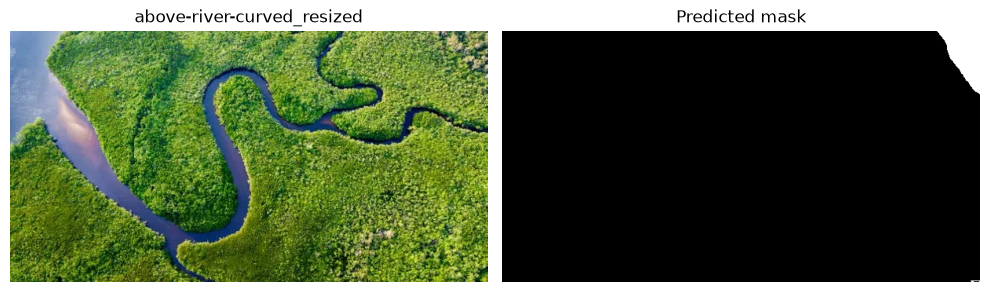

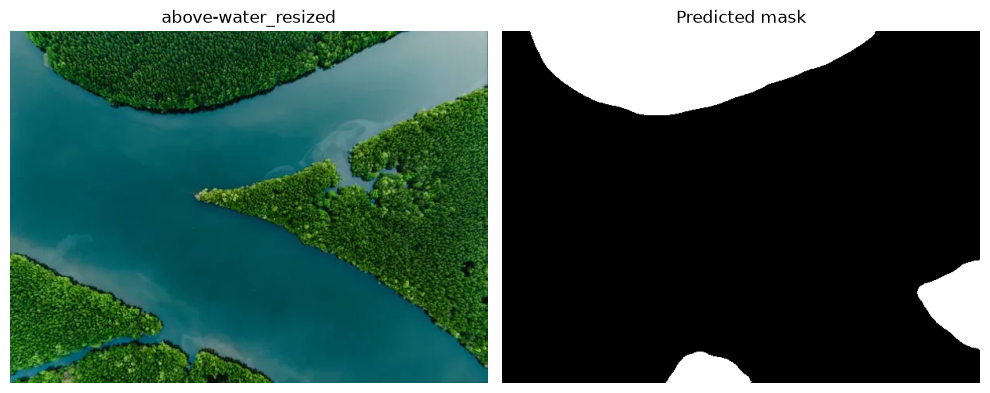

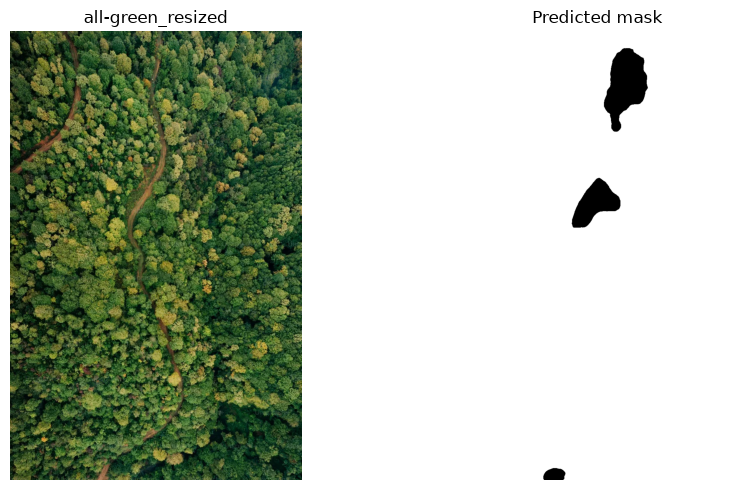

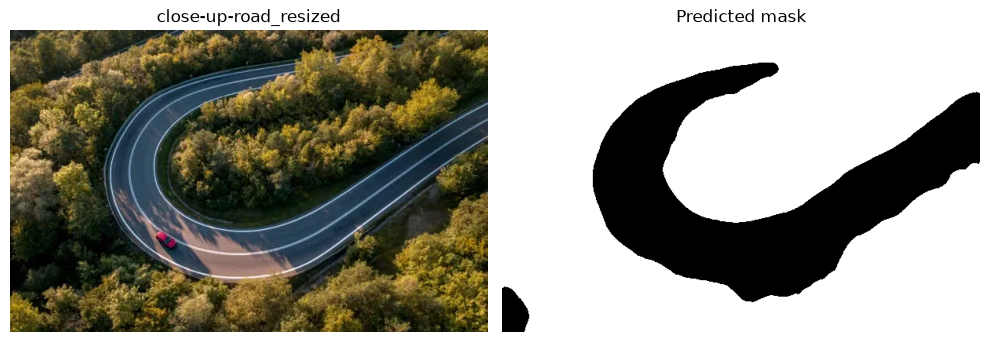

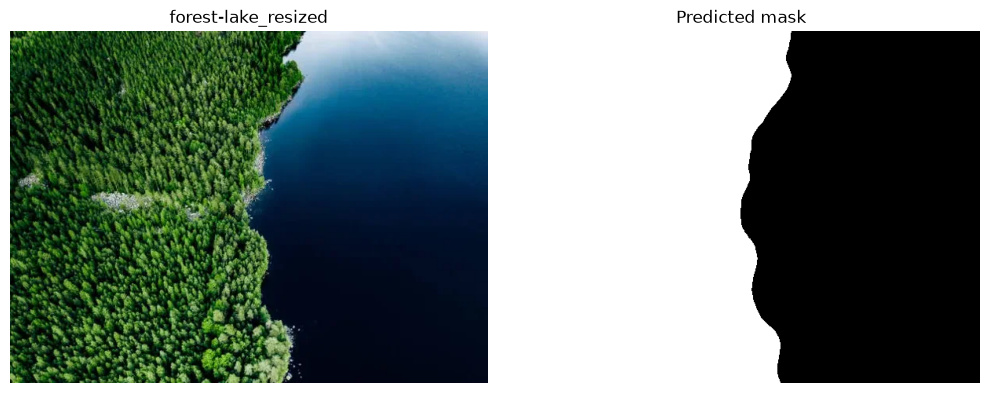

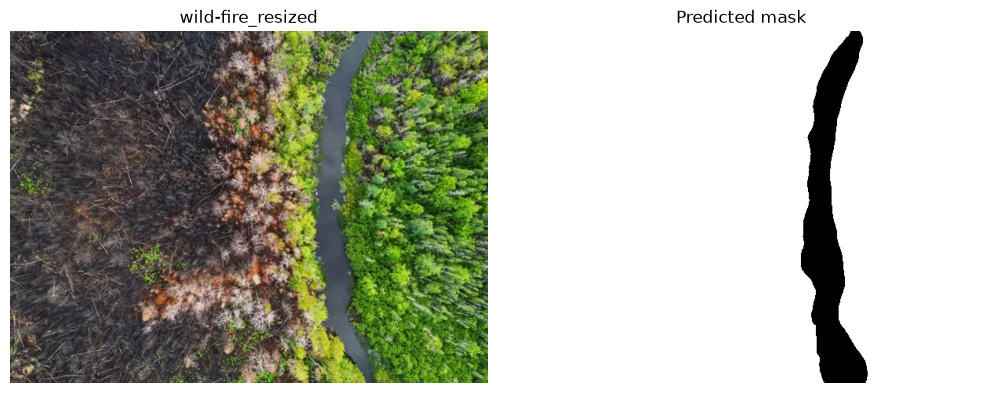

In [48]:
for img_path in resized_image_paths:
    img_resized = Image.open(img_path).convert("RGB")
    img_tensor = TF.to_tensor(img_resized).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred_mask = (torch.sigmoid(output) >= 0.5).float().cpu().squeeze()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_resized)
    axes[0].set_title(img_path.stem)
    axes[0].axis("off")
    axes[1].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Predicted mask")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()